Разбивка на train и val

In [1]:
import os
import shutil
import random

random.seed(42)

source_dir = "simpsons_dataset"
train_dir = "simpsons/train"
val_dir = "simpsons/val"
test_dir = "simpsons/test"

for dir_path in [train_dir, val_dir, test_dir]:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)
    os.makedirs(dir_path, exist_ok=True)

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    
    images = os.listdir(class_path)
    random.shuffle(images)
    
    total = len(images)
    
    if total < 3:
        print(f"Пропускаем класс {class_name}: только {total} изображений")
        continue
    
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)
    

    if total == 3:
        train_images = [images[0]]
        val_images = [images[1]]
        test_images = [images[2]]
    elif total == 4:
        train_images = images[:2]
        val_images = [images[2]]
        test_images = [images[3]]
    else:
        train_end = int(0.7 * total)
        val_end = int(0.85 * total)
        
        train_images = images[:train_end]
        val_images = images[train_end:val_end]
        test_images = images[val_end:]
    
    assert not (set(train_images) & set(val_images)), "Пересечение train и val!"
    assert not (set(train_images) & set(test_images)), "Пересечение train и test!"
    assert not (set(val_images) & set(test_images)), "Пересечение val и test!"
    
    for img in train_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(train_dir, class_name, img))
    for img in val_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(val_dir, class_name, img))
    for img in test_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(test_dir, class_name, img))

print("Разбиение завершено. Пересечений нет.")

Разбиение завершено. Пересечений нет.


In [2]:
import os

train_dir = "simpsons/train"
val_dir = "simpsons/val"

train_files = {}
val_files = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        train_files[class_name] = set(os.listdir(class_path))

for class_name in os.listdir(val_dir):
    class_path = os.path.join(val_dir, class_name)
    if os.path.isdir(class_path):
        val_files[class_name] = set(os.listdir(class_path))

duplicates = {}
all_classes = set(train_files.keys()) | set(val_files.keys())

for class_name in all_classes:
    train_set = train_files.get(class_name, set())
    val_set = val_files.get(class_name, set())
    common = train_set & val_set
    if common:
        duplicates[class_name] = common

if duplicates:
    print("Найдены дубликаты между train и val:")
    for class_name, files in duplicates.items():
        print(f"Класс {class_name}: {files}")
else:
    print("Дубликатов не найдено.")

Дубликатов не найдено.


In [3]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.461, 0.408, 0.353], std=[0.254, 0.231, 0.262])
])

val_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root='simpsons/train', transform=train_transform)
val_dataset = datasets.ImageFolder(root='simpsons/val', transform=val_test_transform)
test_dataset = datasets.ImageFolder(root='simpsons/test', transform=val_test_transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=6)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=6)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=6)

num_classes = len(train_dataset.classes)
print(f'Классы: {train_dataset.classes}')
print(f'Всего классов: {num_classes}')
print(f'Размер train: {len(train_dataset)}')
print(f'Размер val: {len(val_dataset)}')
print(f'Размер test: {len(test_dataset)}')

Классы: ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson', 'carl_carlson', 'charles_montgomery_burns', 'chief_wiggum', 'cletus_spuckler', 'comic_book_guy', 'disco_stu', 'edna_krabappel', 'fat_tony', 'gil', 'groundskeeper_willie', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lenny_leonard', 'lionel_hutz', 'lisa_simpson', 'maggie_simpson', 'marge_simpson', 'martin_prince', 'mayor_quimby', 'milhouse_van_houten', 'miss_hoover', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'otto_mann', 'patty_bouvier', 'principal_skinner', 'professor_john_frink', 'rainier_wolfcastle', 'ralph_wiggum', 'selma_bouvier', 'sideshow_bob', 'sideshow_mel', 'snake_jailbird', 'troy_mcclure', 'waylon_smithers']
Всего классов: 42
Размер train: 14632
Размер val: 3141
Размер test: 3160


In [4]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

        self._init_weights_he()
    
    def _init_weights_he(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.bn4(self.conv4(x)))
        
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [9]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = SimpleCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 30
best_val_acc = 0.0
best_model_path = 'best_model.pth'

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = correct / total
    print(f'Эпоха {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Acc: {val_acc:.4f}')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f'  -> Новая лучшая модель! Val Acc: {val_acc:.4f}')

print(f'Обучение завершено. Лучшая точность на val: {best_val_acc:.4f}')

cuda


Эпоха 1/30, Loss: 2.6080, Val Acc: 0.3875
  -> Новая лучшая модель! Val Acc: 0.3875
Эпоха 2/30, Loss: 1.8360, Val Acc: 0.5807
  -> Новая лучшая модель! Val Acc: 0.5807
Эпоха 3/30, Loss: 1.4701, Val Acc: 0.5002
Эпоха 4/30, Loss: 1.2275, Val Acc: 0.7380
  -> Новая лучшая модель! Val Acc: 0.7380
Эпоха 5/30, Loss: 1.0826, Val Acc: 0.7373
Эпоха 6/30, Loss: 0.9597, Val Acc: 0.7281
Эпоха 7/30, Loss: 0.8744, Val Acc: 0.7587
  -> Новая лучшая модель! Val Acc: 0.7587
Эпоха 8/30, Loss: 0.8032, Val Acc: 0.7953
  -> Новая лучшая модель! Val Acc: 0.7953
Эпоха 9/30, Loss: 0.7488, Val Acc: 0.8268
  -> Новая лучшая модель! Val Acc: 0.8268
Эпоха 10/30, Loss: 0.7058, Val Acc: 0.8453
  -> Новая лучшая модель! Val Acc: 0.8453
Эпоха 11/30, Loss: 0.6503, Val Acc: 0.8048
Эпоха 12/30, Loss: 0.6265, Val Acc: 0.7927
Эпоха 13/30, Loss: 0.5747, Val Acc: 0.8274
Эпоха 14/30, Loss: 0.5408, Val Acc: 0.8478
  -> Новая лучшая модель! Val Acc: 0.8478
Эпоха 15/30, Loss: 0.5198, Val Acc: 0.8271
Эпоха 16/30, Loss: 0.4858, V

Визуальный тест

In [6]:
print(f"train_loader workers: {train_loader.num_workers}")

train_loader workers: 6


F1 Score на test

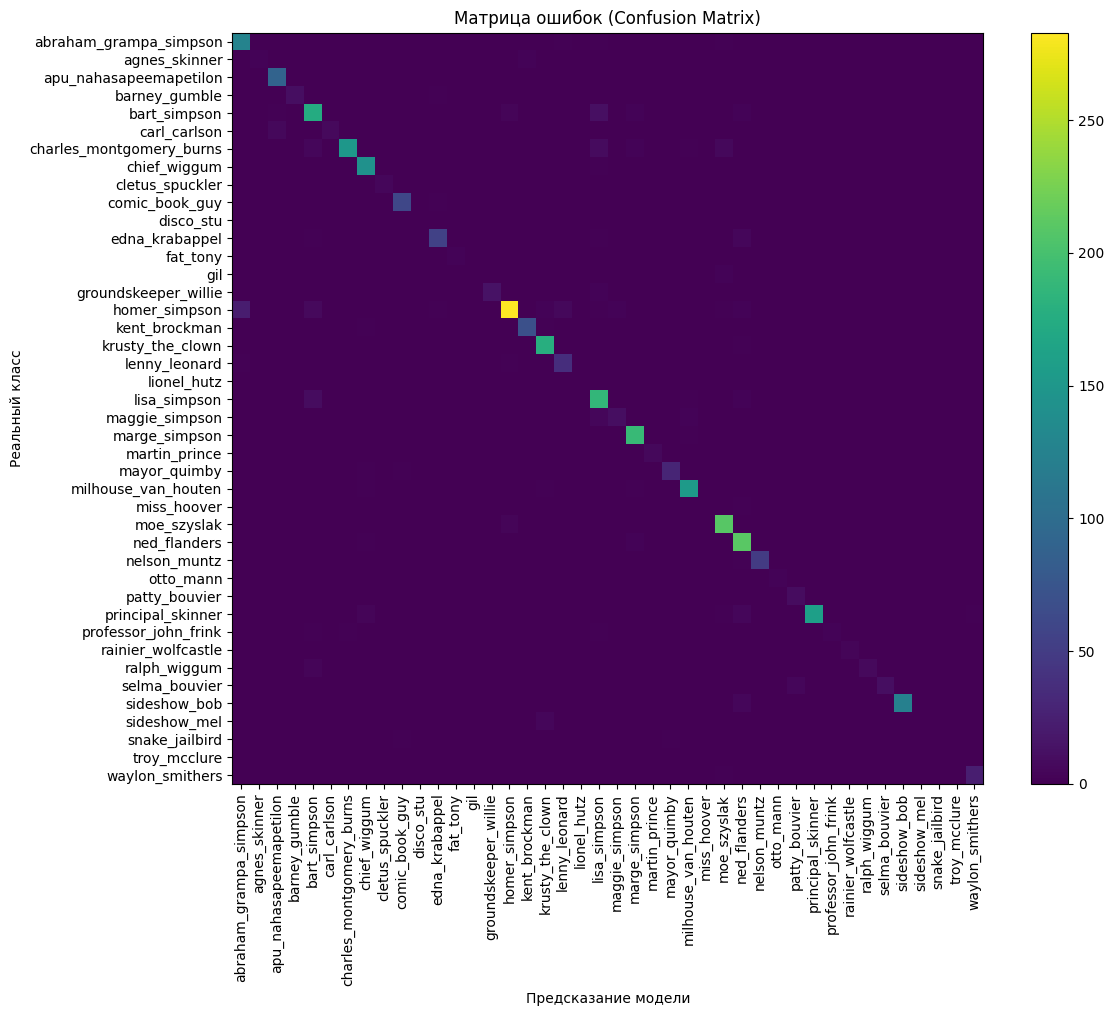

Accuracy на тесте: 0.8864
F1-macro на тесте: 0.7064

Детальный отчёт по классам:
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.80      0.93      0.86       137
           agnes_skinner       1.00      0.43      0.60         7
  apu_nahasapeemapetilon       0.87      0.96      0.91        94
           barney_gumble       0.71      0.62      0.67        16
            bart_simpson       0.84      0.86      0.85       202
            carl_carlson       0.88      0.47      0.61        15
charles_montgomery_burns       0.96      0.84      0.90       179
            chief_wiggum       0.88      0.97      0.92       148
         cletus_spuckler       1.00      0.62      0.77         8
          comic_book_guy       0.86      0.85      0.85        71
               disco_stu       0.00      0.00      0.00         2
          edna_krabappel       0.83      0.80      0.81        69
                fat_tony       1.00      0.60      0.75     

/home/yuki/University/2_course/Programming/ai/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/yuki/University/2_course/Programming/ai/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/yuki/University/2_course/Programming/ai/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix   
import matplotlib.pyplot as plt
import numpy as np


best_model_path = "best_model.pth"
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap='viridis')
plt.title('Матрица ошибок (Confusion Matrix)')
plt.colorbar()


tick_marks = np.arange(len(train_dataset.classes))
plt.xticks(tick_marks, train_dataset.classes, rotation=90)
plt.yticks(tick_marks, train_dataset.classes)

plt.ylabel('Реальный класс')
plt.xlabel('Предсказание модели')
plt.tight_layout()
plt.show()

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Accuracy на тесте: {accuracy:.4f}")

f1_macro = f1_score(all_labels, all_preds, average='macro')
print(f"F1-macro на тесте: {f1_macro:.4f}")

print("\nДетальный отчёт по классам:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))